## **Applied Models :**

1. Random Forest

2. XGBoost

3. Logistic Regression

4. SVM

5. KNN 

**Importing**

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## **Loading Data**

In [29]:
df = pd.read_csv('./input/star_classification.csv')
df.head(5)

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237660e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543780e+18,GALAXY,0.634794,5812,56354,171
1,1.237660e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176010e+19,GALAXY,0.779136,10445,58158,427
2,1.237660e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237660e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030110e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891860e+18,GALAXY,0.116123,6121,56187,842


## **Exploratory Data Analysis (EDA)**

In [30]:
print("Dataset Shape:")
df.shape

Dataset Shape:


(100000, 18)

In [31]:
df["class"].value_counts()

class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64

In [32]:
print("Dataset Columns Name:")
df.columns

Dataset Columns Name:


Index(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
       'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift',
       'plate', 'MJD', 'fiber_ID'],
      dtype='object')

In [33]:
print("Missing Values:") # How many missing value?
df.isnull().sum()

Missing Values:


obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64

In [34]:
df.info() # Show detaile columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [35]:
for col in df.columns: #Column Information
    print(f"Column Name: {col}")
    print(f"Data Type: {df[col].dtype}")
    print(f"Unique Values: {df[col].nunique()}")
    print(f"Missing Values: {df[col].isnull().sum()}")
    print("-" * 40)

Column Name: obj_ID
Data Type: float64
Unique Values: 5
Missing Values: 0
----------------------------------------
Column Name: alpha
Data Type: float64
Unique Values: 99997
Missing Values: 0
----------------------------------------
Column Name: delta
Data Type: float64
Unique Values: 99999
Missing Values: 0
----------------------------------------
Column Name: u
Data Type: float64
Unique Values: 93748
Missing Values: 0
----------------------------------------
Column Name: g
Data Type: float64
Unique Values: 92651
Missing Values: 0
----------------------------------------
Column Name: r
Data Type: float64
Unique Values: 91901
Missing Values: 0
----------------------------------------
Column Name: i
Data Type: float64
Unique Values: 92019
Missing Values: 0
----------------------------------------
Column Name: z
Data Type: float64
Unique Values: 92007
Missing Values: 0
----------------------------------------
Column Name: run_ID
Data Type: int64
Unique Values: 430
Missing Values: 0
-----

In [36]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
obj_ID,100000.0,1.237688e+18,2.311624e+14,1.237650e+18,1.237660e+18,1.237660e+18,1.237670e+18,1.240000e+18
alpha,100000.0,1.776291e+02,9.650224e+01,5.527828e-03,1.275182e+02,1.809007e+02,2.338950e+02,3.599998e+02
delta,100000.0,2.413530e+01,1.964467e+01,-1.878533e+01,5.146771e+00,2.364592e+01,3.990155e+01,8.300052e+01
u,100000.0,2.198047e+01,3.176929e+01,-9.999000e+03,2.035235e+01,2.217914e+01,2.368744e+01,3.278139e+01
g,100000.0,2.053139e+01,3.175029e+01,-9.999000e+03,1.896523e+01,2.109983e+01,2.212377e+01,3.160224e+01
r,100000.0,1.964576e+01,1.854760e+00,9.822070e+00,1.813583e+01,2.012529e+01,2.104478e+01,2.957186e+01
i,100000.0,1.908485e+01,1.757895e+00,9.469903e+00,1.773228e+01,1.940514e+01,2.039650e+01,3.214147e+01
z,100000.0,1.866881e+01,3.172815e+01,-9.999000e+03,1.746068e+01,1.900460e+01,1.992112e+01,2.938374e+01
run_ID,100000.0,4.481366e+03,1.964765e+03,1.090000e+02,3.187000e+03,4.188000e+03,5.326000e+03,8.162000e+03
rerun_ID,100000.0,3.010000e+02,0.000000e+00,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02


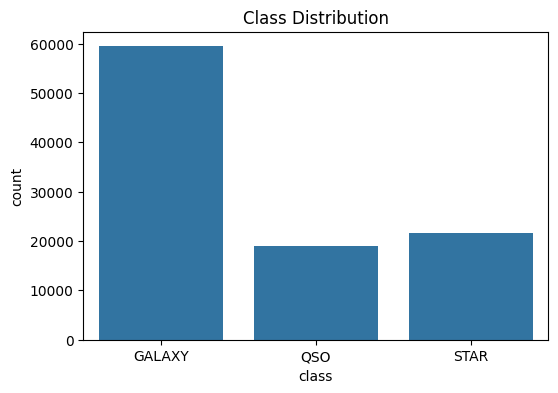

In [37]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['class'])
plt.title('Class Distribution')
plt.show()

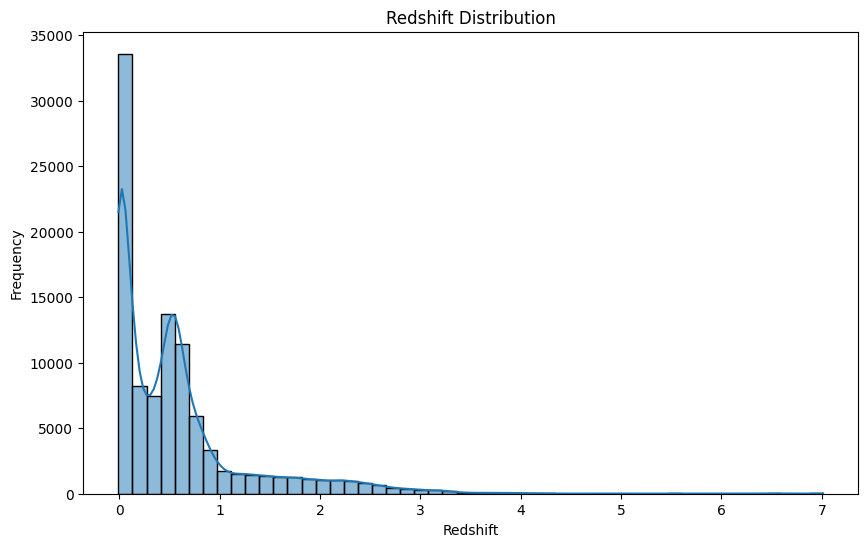

In [38]:
plt.figure(figsize=(10,6))
sns.histplot(df['redshift'], bins=50, kde=True)
plt.title("Redshift Distribution")
plt.xlabel("Redshift")
plt.ylabel("Frequency")
plt.show()

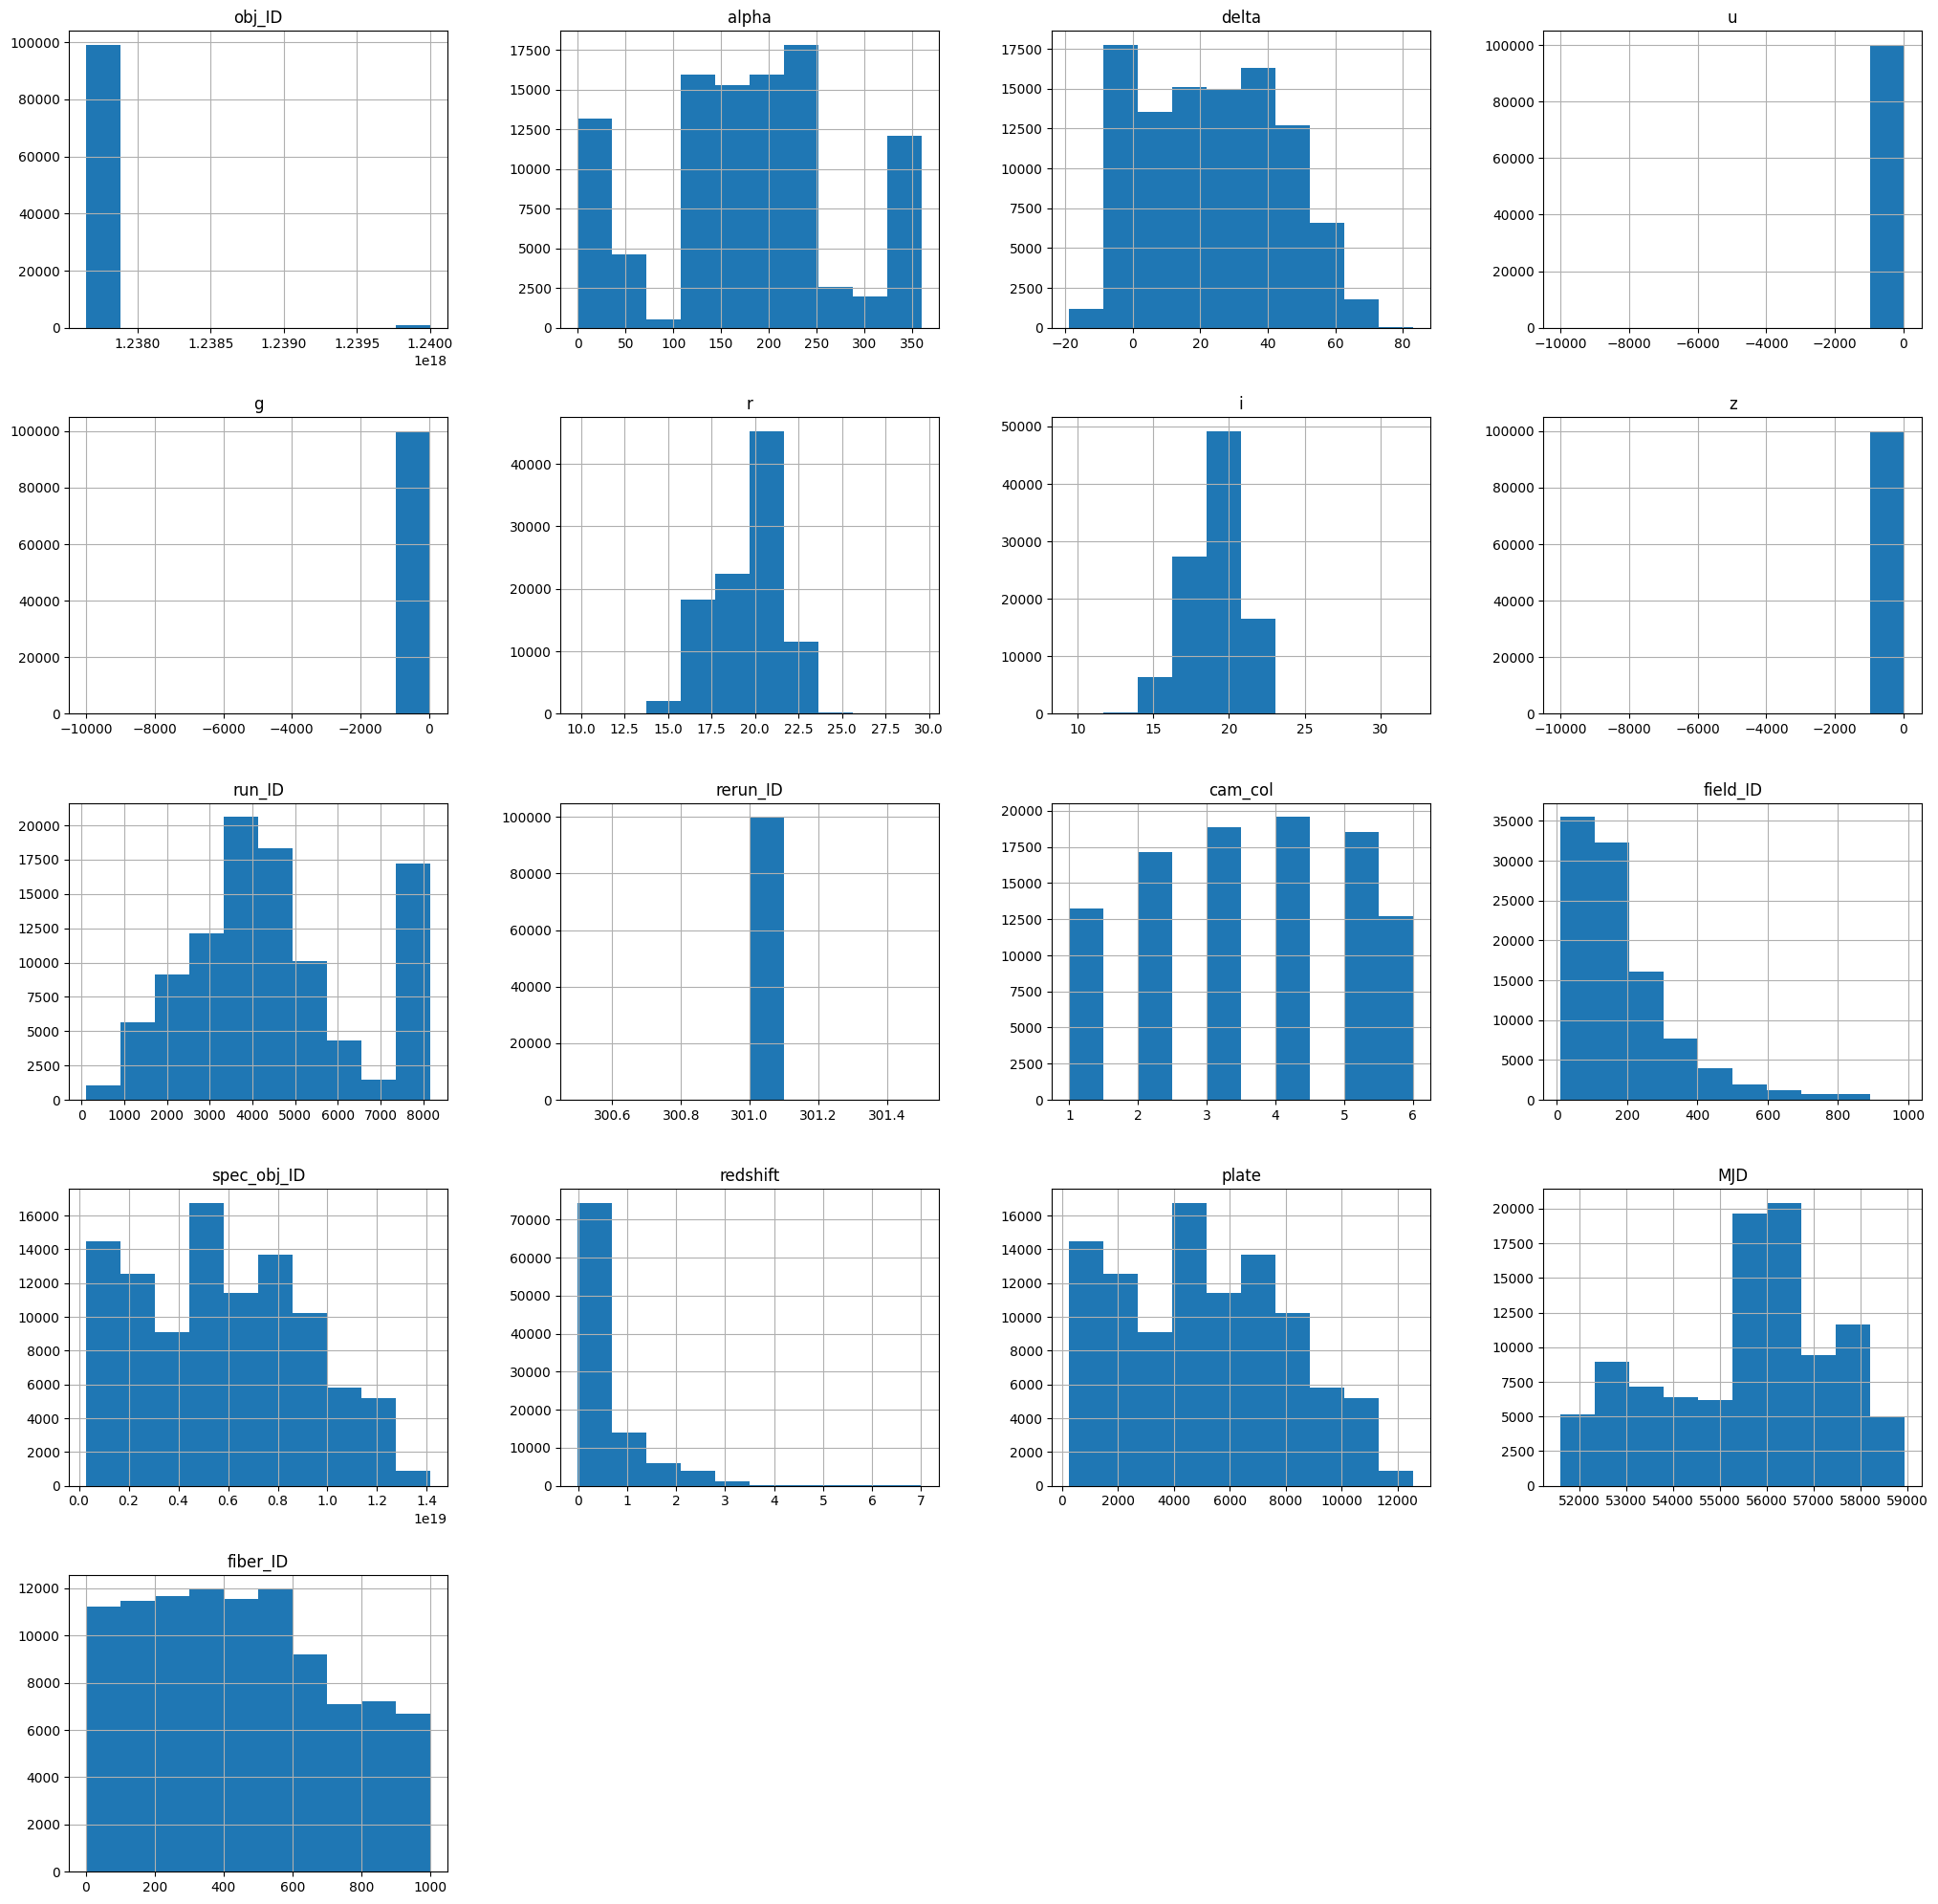

In [39]:
df.hist(figsize=(25, 25)) #histogram
plt.show()

## **Preprocessing Data**

In [40]:
text_columns = [ 
    'obj_ID',
    'spec_obj_ID'
]
for col in text_columns:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

In [41]:
for col in df.columns: #Nan Control
    
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

In [42]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

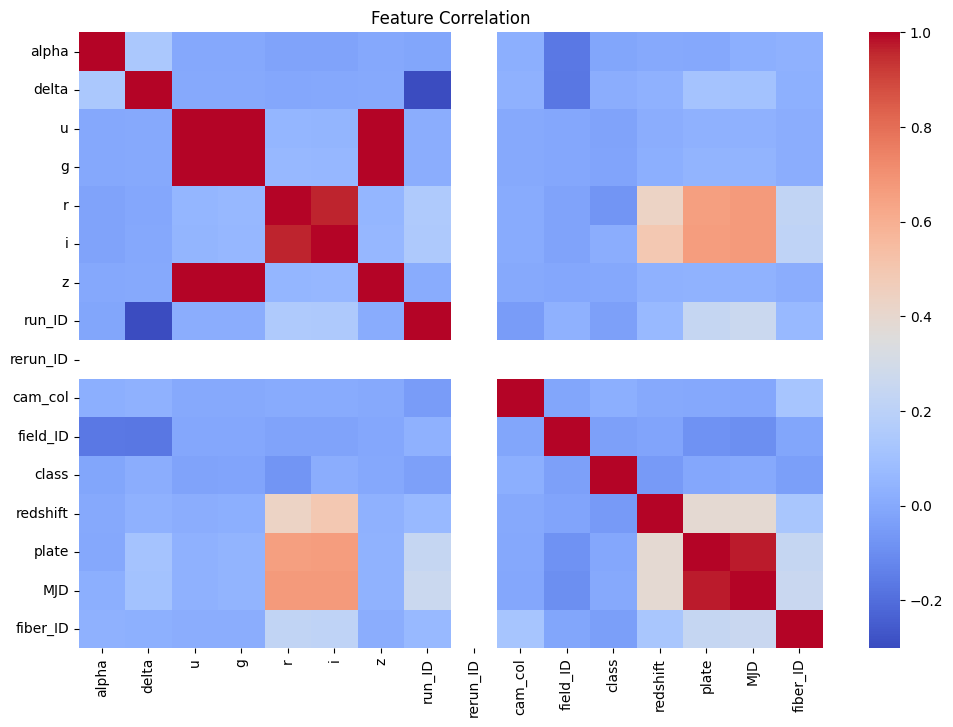

In [43]:
plt.figure(figsize=(12,8))
#numeric_df = df.select_dtypes(include='number')
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation")
plt.show()

**Split Feature & Target**

In [44]:
TARGET_COLUMN = "class"
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

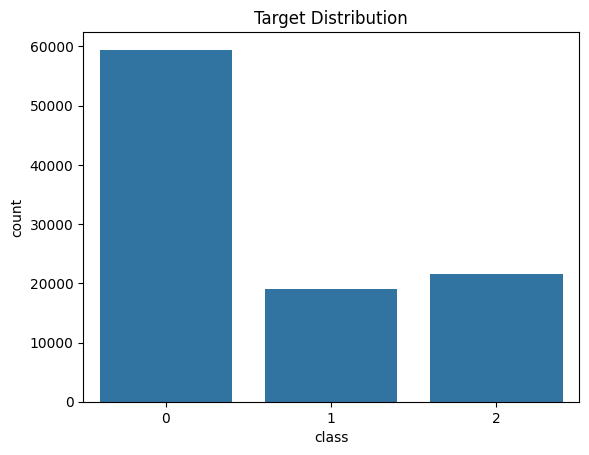

In [45]:
sns.countplot(x=y)
plt.title("Target Distribution")
plt.show()

**Train & Test Split**

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)

## **Feature Scaling**

In [47]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Model Training**

## Random Forest

**Creating & Training Random Forest Model**

In [48]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [49]:
#from sklearn.model_selection import GridSearchCV

#p = {'n_estimators': [50,100,200],'max_depth': [5,10,15],'min_samples_split': [2,5,10],'criterion': ['gini', 'entropy']}
#g = GridSearchCV(rf,p,cv=5,n_jobs=-1)

#g.fit(X_train, y_train)
#print(g.best_params_)
#print(g.best_score_)

**Metrics**

In [50]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average='weighted')
rf_recall = recall_score(y_test, y_pred_rf, average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

print(f"\nAccuracy: {rf_accuracy * 100:.2f}%")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1 Score: {rf_f1:.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Accuracy: 97.85%
Precision: 0.9784
Recall: 0.9785
F1 Score: 0.9784

Confusion Matrix:
[[11708   117    64]
 [  247  3545     0]
 [    2     0  4317]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11889
           1       0.97      0.93      0.95      3792
           2       0.99      1.00      0.99      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000



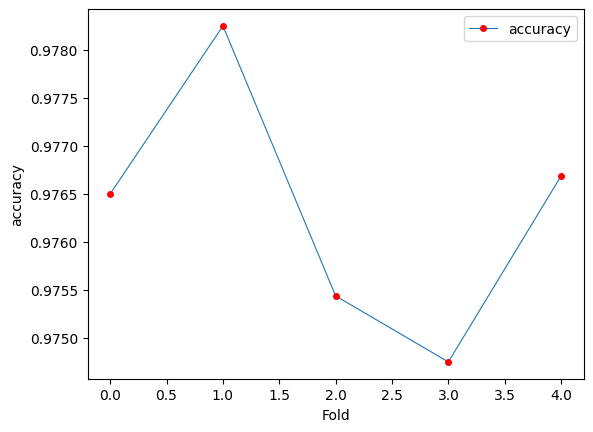

In [51]:
scores = cross_val_score(rf, X_train, y_train,cv=5, scoring='accuracy')

plt.plot(scores, label='accuracy',marker='o',ms=4,mfc='r',mec='r',linewidth=0.8)
plt.xlabel('Fold')
plt.ylabel('accuracy')
plt.legend()
plt.show()

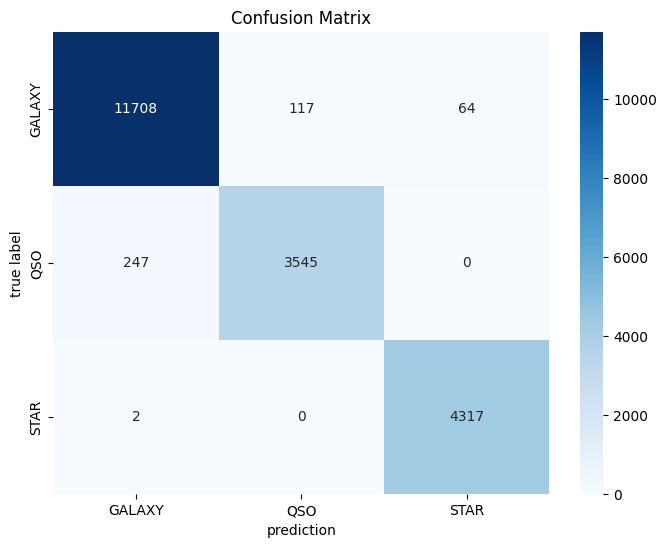

In [52]:
lb = le.classes_
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=lb, yticklabels=lb)
plt.xlabel("prediction")
plt.ylabel('true label')
plt.title('Confusion Matrix')
plt.show()

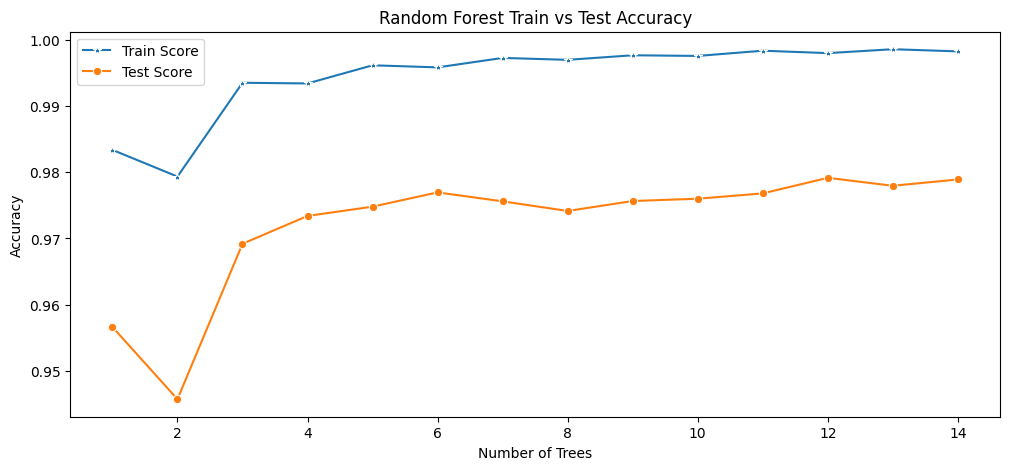

In [53]:
train_scores = []
test_scores = []

for i in range(1,15):
    m = RandomForestClassifier(i)
    m.fit(X_train, y_train)
    train_scores.append(m.score(X_train, y_train))
    test_scores.append(m.score(X_test, y_test))
plt.figure(figsize=(12,5))

# Pass keyword arguments x= and y=
sns.lineplot(x=range(1,15), y=train_scores, marker='*', label='Train Score')
sns.lineplot(x=range(1,15), y=test_scores, marker='o', label='Test Score')

plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Random Forest Train vs Test Accuracy")
plt.legend()
plt.show()

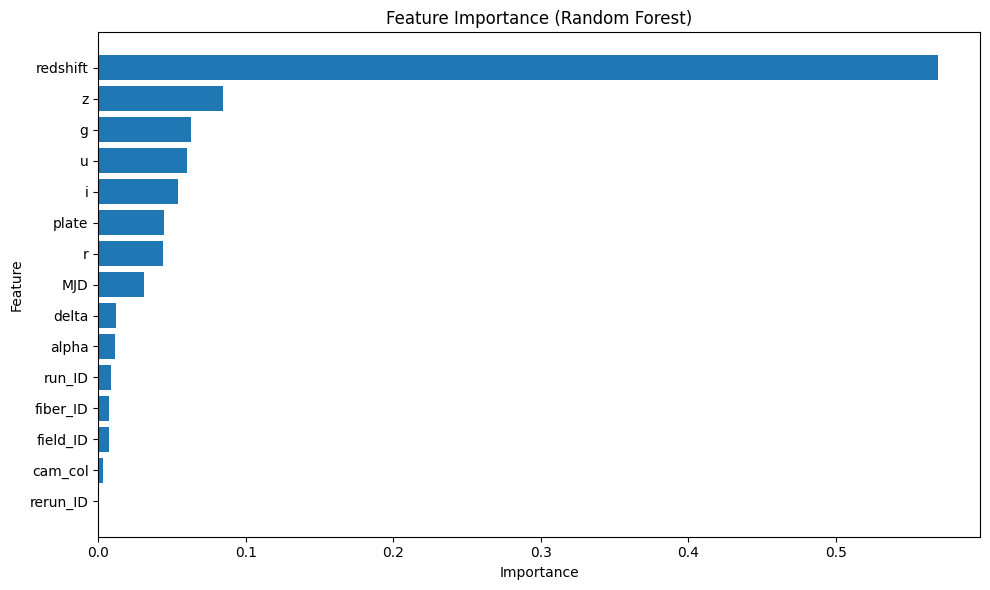

In [54]:
importance = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
importance = importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance['Feature'], importance['Importance'])
plt.gca().invert_yaxis()  
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

## XGBoost

**Creating & Training XGBoost Model**

In [55]:
xg = XGBClassifier(n_estimators=200, max_depth=6)
xg.fit(X_train, y_train)
y_pred_xg = xg.predict(X_test)

In [56]:
#from sklearn.model_selection import GridSearchCV

#p = {'n_estimators': [50,100,200],'max_depth': [5,10,15]}
#g = GridSearchCV(xg,p,cv=5,n_jobs=-1)

#g.fit(X_train, y_train)
#print(g.best_params_)
#print(g.best_score_)

**Metrics**

In [57]:
xg_accuracy = accuracy_score(y_test, y_pred_xg)
xg_precision = precision_score(y_test, y_pred_xg, average='weighted')
xg_recall = recall_score(y_test, y_pred_xg, average='weighted')
xg_f1 = f1_score(y_test, y_pred_xg, average='weighted')

print(f"\nAccuracy: {xg_accuracy * 100:.2f}%")
print(f"Precision: {xg_precision:.4f}")
print(f"Recall: {xg_recall:.4f}")
print(f"F1 Score: {xg_f1:.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_xg)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xg))


Accuracy: 97.76%
Precision: 0.9775
Recall: 0.9776
F1 Score: 0.9775

Confusion Matrix:
[[11705   128    56]
 [  243  3548     1]
 [   20     0  4299]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11889
           1       0.97      0.94      0.95      3792
           2       0.99      1.00      0.99      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000



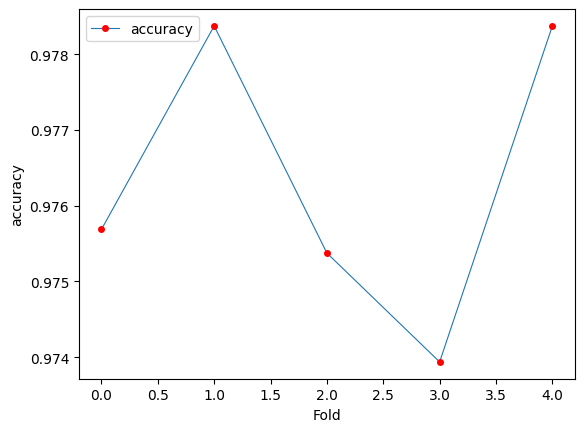

In [58]:
scores = cross_val_score(xg, X_train, y_train,cv=5, scoring='accuracy')

plt.plot(scores, label='accuracy',marker='o',ms=4,mfc='r',mec='r',linewidth=0.8)
plt.xlabel('Fold')
plt.ylabel('accuracy')
plt.legend()
plt.show()

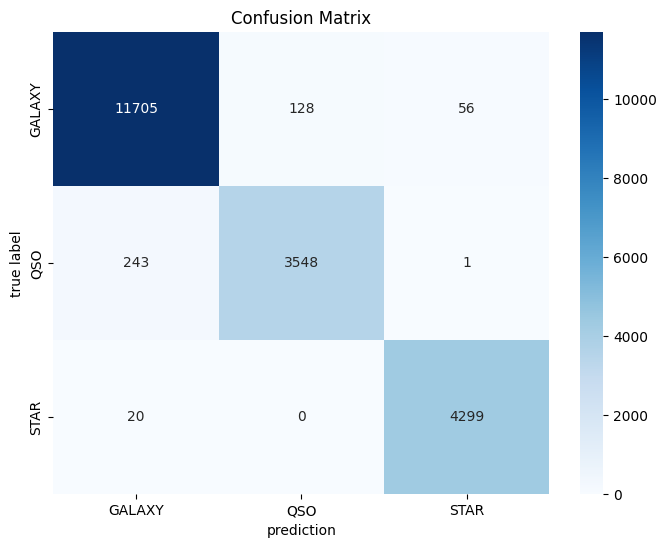

In [59]:
lb = le.classes_
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=lb, yticklabels=lb)
plt.xlabel("prediction")
plt.ylabel('true label')
plt.title('Confusion Matrix')
plt.show()

## Logistic Regression

**Creating & Training KNN Model**

In [60]:
log_reg = LogisticRegression(max_iter=1000, multi_class='multinomial')
log_reg.fit(X_train_scaled, y_train)
y_pred_log_reg = log_reg.predict(X_test_scaled)

In [61]:
#from sklearn.model_selection import GridSearchCV

#p = {'C': [0.01, 0.1, 1, 10],'solver': ['lbfgs'],'max_iter': [1000]}
#g = GridSearchCV(log_reg,p,cv=5,n_jobs=-1)

#g.fit(X_train_scaled, y_train)
#print(g.best_params_)
#print(g.best_score_)

**Metrics**

In [62]:
log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)
log_reg_precision = precision_score(y_test, y_pred_log_reg, average='weighted')
log_reg_recall = recall_score(y_test, y_pred_log_reg, average='weighted')
log_reg_f1 = f1_score(y_test, y_pred_log_reg, average='weighted')

print(f"\nAccuracy: {log_reg_accuracy * 100:.2f}%")
print(f"Precision: {log_reg_precision:.4f}")
print(f"Recall: {log_reg_recall:.4f}")
print(f"F1 Score: {log_reg_f1:.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_log_reg)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg))


Accuracy: 95.71%
Precision: 0.9572
Recall: 0.9571
F1 Score: 0.9567

Confusion Matrix:
[[11496   154   239]
 [  457  3332     3]
 [    1     3  4315]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96     11889
           1       0.96      0.88      0.92      3792
           2       0.95      1.00      0.97      4319

    accuracy                           0.96     20000
   macro avg       0.95      0.95      0.95     20000
weighted avg       0.96      0.96      0.96     20000



In [63]:
#scores = cross_val_score(log_reg, X_train, y_train ,cv=5, scoring='accuracy')

#plt.plot(scores, label='accuracy',marker='o',ms=4,mfc='r',mec='r',linewidth=0.8)
#plt.xlabel('Fold')
#plt.ylabel('accuracy')
#plt.legend()
#plt.show()

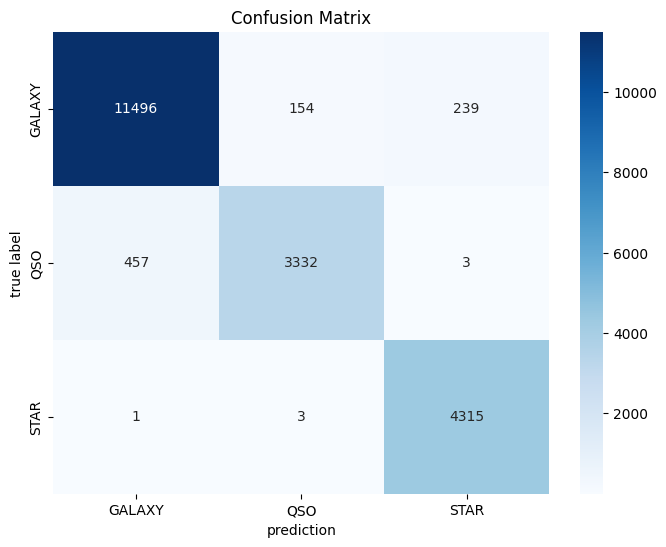

In [64]:
lb = le.classes_
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=lb, yticklabels=lb)
plt.xlabel("prediction")
plt.ylabel('true label')
plt.title('Confusion Matrix')
plt.show()

## SVM

**Creating & Training SVM Model**

In [65]:
svm = SVC(kernel='rbf')
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

In [66]:
#from sklearn.model_selection import GridSearchCV

#p={'kernel':['linear','poly','rbf'],'gamma':['scale','auto'],'degree':[1,2,4,5,6]}

#g = GridSearchCV(svm, p, n_jobs=-1, cv=5)
#g.fit(X, y)
#print(g.best_params_)

**Metrics**

In [67]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm, average='weighted')
svm_recall = recall_score(y_test, y_pred_svm, average='weighted')
svm_f1 = f1_score(y_test, y_pred_svm, average='weighted')

print(f"\nAccuracy: {svm_accuracy * 100:.2f}%")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall: {svm_recall:.4f}")
print(f"F1 Score: {svm_f1:.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_svm)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))


Accuracy: 95.94%
Precision: 0.9596
Recall: 0.9594
F1 Score: 0.9591

Confusion Matrix:
[[11547   107   235]
 [  379  3406     7]
 [   85     0  4234]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97     11889
           1       0.97      0.90      0.93      3792
           2       0.95      0.98      0.96      4319

    accuracy                           0.96     20000
   macro avg       0.96      0.95      0.95     20000
weighted avg       0.96      0.96      0.96     20000



In [68]:
#scores = cross_val_score(svm, X_train, y_train, cv=5, scoring='accuracy')

#plt.plot(scores, label='accuracy',marker='o',ms=4,mfc='r',mec='r',linewidth=0.8)
#plt.xlabel('Fold')
#plt.ylabel('accuracy')
#plt.legend()
#plt.show()

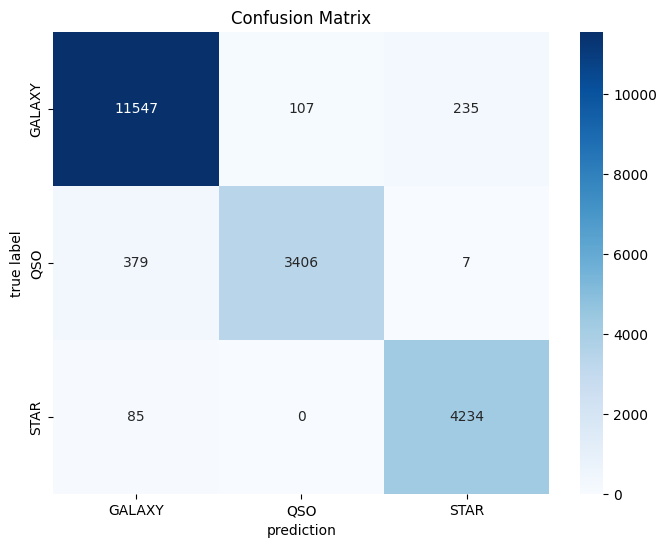

In [69]:
lb = le.classes_
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=lb, yticklabels=lb)
plt.xlabel("prediction")
plt.ylabel('true label')
plt.title('Confusion Matrix')
plt.show()

## KNN

**Creating & Training KNN Model**

In [70]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

In [71]:
#from sklearn.model_selection import GridSearchCV

#p = {'n_neighbors': [3,5,7,9,11],'weights': ['uniform', 'distance'],'metric': ['euclidean', 'manhattan']}
#g = GridSearchCV(knn,p,cv=5,n_jobs=-1)

#g.fit(X_train_scaled, y_train)
#print(g.best_params_)
#print(g.best_score_)

**Metrics**

In [72]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn, average='weighted')
knn_recall = recall_score(y_test, y_pred_knn, average='weighted')
knn_f1 = f1_score(y_test, y_pred_knn, average='weighted')

print(f"\nAccuracy: {knn_accuracy * 100:.2f}%")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall: {knn_recall:.4f}")
print(f"F1 Score: {knn_f1:.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_knn)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))


Accuracy: 90.00%
Precision: 0.9034
Recall: 0.9000
F1 Score: 0.8985

Confusion Matrix:
[[11480    80   329]
 [  639  3119    34]
 [  915     3  3401]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92     11889
           1       0.97      0.82      0.89      3792
           2       0.90      0.79      0.84      4319

    accuracy                           0.90     20000
   macro avg       0.92      0.86      0.88     20000
weighted avg       0.90      0.90      0.90     20000



In [73]:
#scores = cross_val_score(knn, X_train, y_train ,cv=5, scoring='accuracy')

#plt.plot(scores, label='accuracy',marker='o',ms=4,mfc='r',mec='r',linewidth=0.8)
#plt.xlabel('Fold')
#plt.ylabel('accuracy')
#plt.legend()
#plt.show()

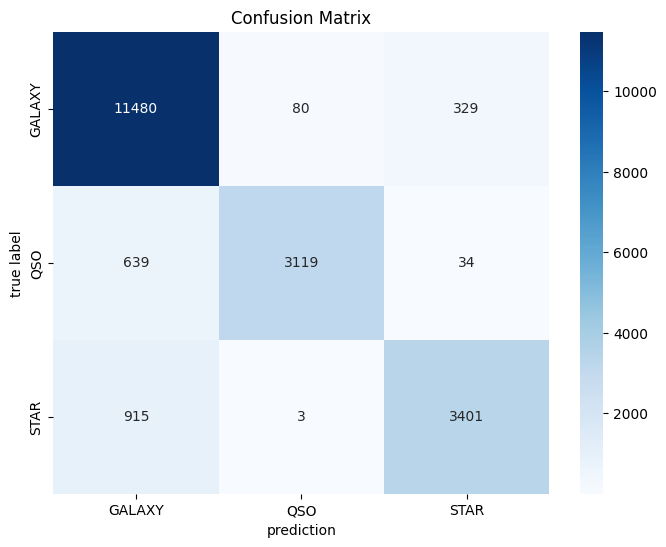

In [74]:
lb = le.classes_
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=lb, yticklabels=lb)
plt.xlabel("prediction")
plt.ylabel('true label')
plt.title('Confusion Matrix')
plt.show()

# **Ploting Results**

In [75]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "Logistic Regression",
        "SVM",  
        "KNN"
    ],

    "Accuracy": [
        rf_accuracy * 100,
        xg_accuracy * 100,
        log_reg_accuracy * 100,
        svm_accuracy * 100,
        knn_accuracy * 100
    ]
})

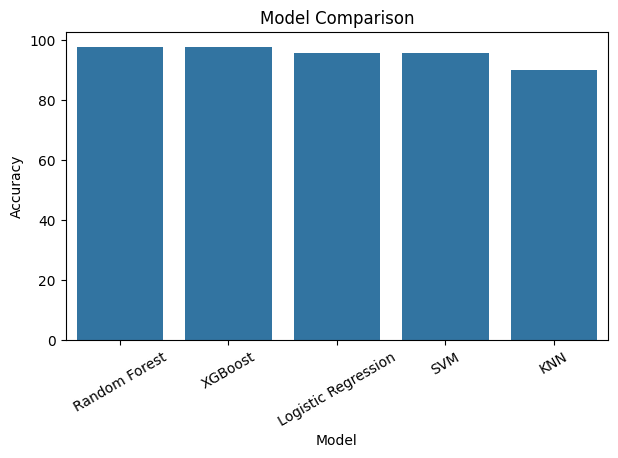

In [76]:
plt.figure(figsize=(7,4))
sns.barplot(x='Model', y='Accuracy', data=results)
plt.title('Model Comparison')
plt.xticks(rotation=30)
plt.show()

# **Conclusion: Best Algorithm is ...**

In [77]:
print(f"Random Forest Accuracy: {rf_accuracy*100:.2f}%")
print(f"XGBoost Accuracy: {xg_accuracy*100:.2f}%")
print(f"Logistic Regression Accuracy: {log_reg_accuracy*100:.2f}%")
print(f"SVM Accuracy: {svm_accuracy*100:.2f}%")
print(f"KNN Accuracy: {knn_accuracy*100:.2f}%")
print("\nBest Model: Random Forest")

Random Forest Accuracy: 97.85%
XGBoost Accuracy: 97.76%
Logistic Regression Accuracy: 95.71%
SVM Accuracy: 95.94%
KNN Accuracy: 90.00%

Best Model: Random Forest
